In [135]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import *

In [136]:
df=pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [137]:
df.shape

(768, 9)

In [138]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [139]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [140]:
features=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']

X = df[features]
y = df['Outcome']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [141]:
GNB = GaussianNB(priors=[0.4, 0.6])
GNB.fit(X_train, y_train)

y_pred = GNB.predict(X_test)

In [142]:
conf="confussion:", confusion_matrix(y_test, y_pred)
accu="Accuracy:", accuracy_score(y_test, y_pred)
precision="Precision:", precision_score(y_test, y_pred)
recall="Recall:", recall_score(y_test, y_pred)
f1="F1_score:", f1_score(y_test,y_pred)
rc="ROC-AUC:", roc_auc_score(y_test, y_pred)

print(conf)
print(accu)
print(precision)
print(recall)
print(f1)
print(rc)

('confussion:', array([[64, 35],
       [ 9, 46]]))
('Accuracy:', 0.7142857142857143)
('Precision:', 0.5679012345679012)
('Recall:', 0.8363636363636363)
('F1_score:', 0.6764705882352942)
('ROC-AUC:', 0.7414141414141414)


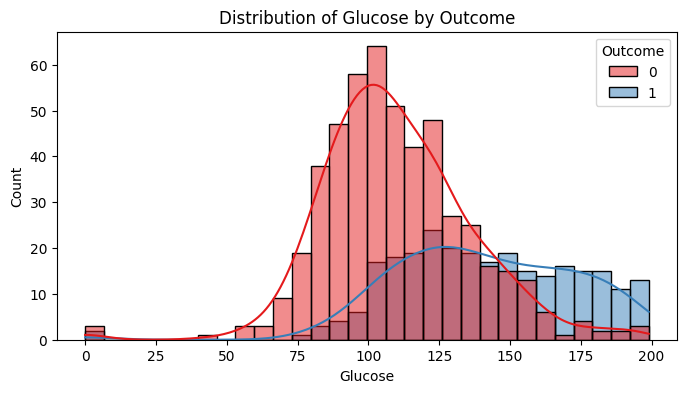

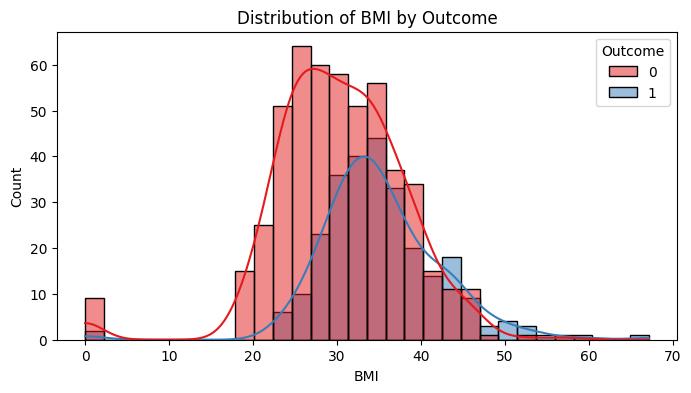

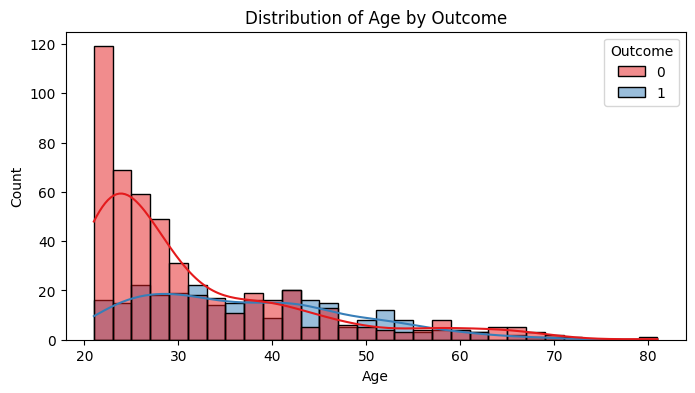

In [ ]:
import seaborn as sns

features = ['Glucose','BMI','Age']

for feature in features:
    plt.figure(figsize=(8,4))
    sns.histplot(df, x=feature, hue='Outcome', kde=True, palette='Set1', bins=30)
    plt.title(f'Distribution of {feature} by Outcome')
    plt.show()

* These graphs are distribution plots (histograms with smooth curves) that compare health features between two groups:
* Outcome = 0 → people without diabetes
* Outcome = 1 → people with diabetes
* Red bars/curve (0) = non-diabetic
* Blue bars/curve (1) = diabetic
* Select some key features

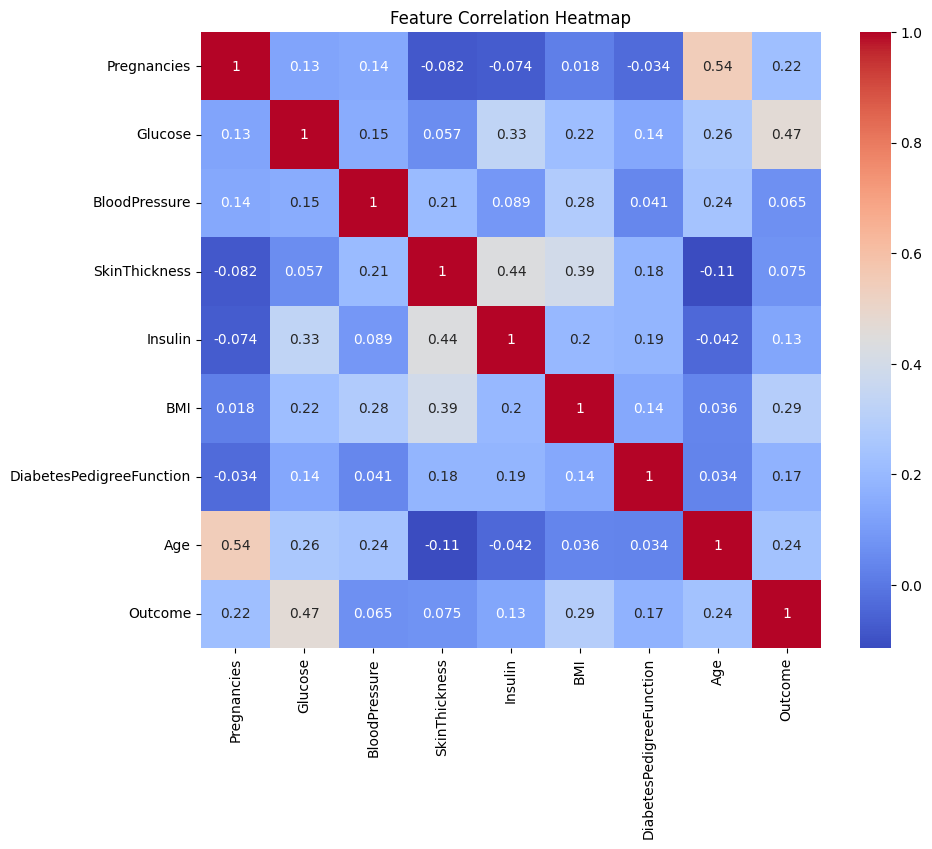

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

* The number inside (from -1 to +1) shows the relationship:
* +1 → strong positive relationship (both increase together)
*  0 → no relationship
* -1 → strong negative relationship (one increases, the other decreases)

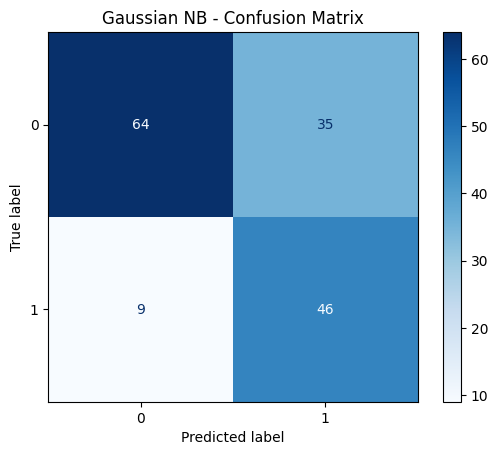

In [145]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(GNB, X_test, y_test, cmap='Blues')
plt.title('Gaussian NB - Confusion Matrix')
plt.show()